# 05 — Feature Extraction + PyTorch Grade Classifier

**Pipeline:**
1. Load labeled images from `datasets/unified/psa{1-10}/`
2. Extract two feature types per image:
   - **CV features** (20-dim): corner sharpness, edge quality, surface cleanliness, centering — from `grading_utils`
   - **CNN features** (512-dim): pretrained ResNet-18 backbone embeddings
3. Cache features to disk so extraction runs once
4. Train three MLP variants and compare:
   - `CV-MLP` — interpretable, fast, 20 inputs
   - `CNN-MLP` — powerful, 512 inputs
   - `Combined-MLP` — both fused, 532 inputs
5. Evaluate: confusion matrix, per-grade accuracy, feature importance
6. Save best model to `grade_mlp_best.pt`

**Label:** PSA grades 1–10 bucketed into 5 classes:

| Bucket | Grades | Name |
|--------|--------|------|
| 0 | 1–2 | Poor |
| 1 | 3–4 | Very Good |
| 2 | 5–6 | Excellent |
| 3 | 7–8 | Near Mint |
| 4 | 9–10 | Mint |

**Prerequisites:** Run `04_dataset_acquisition.ipynb` Section 29 to populate `datasets/unified/`.

In [1]:
# ── Install + imports ─────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch', 'torchvision', 'timm',
                       'tqdm', 'scikit-learn', 'matplotlib', 'numpy', 'Pillow'])

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.auto import tqdm
import pickle, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'axes.facecolor': '#0d1117',
    'figure.facecolor': '#0d1117', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white',
})

# ── Constants ─────────────────────────────────────────────────────
PSA_TO_BUCKET = {1:0,2:0, 3:1,4:1, 5:2,6:2, 7:3,8:3, 9:4,10:4}
BUCKET_NAMES  = ['Poor\n(1-2)', 'VG\n(3-4)', 'Excellent\n(5-6)', 'NM\n(7-8)', 'Mint\n(9-10)']
NUM_CLASSES   = 5
CARD_H, CARD_W = 420, 300

DEVICE = torch.device('cuda'  if torch.cuda.is_available() else
                      'mps'   if torch.backends.mps.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

import timm
print(f'timm   : {timm.__version__}')

# ── Auto-detect dataset ───────────────────────────────────────────
def _count_images(root: Path) -> int:
    return sum(len(list((root / f'psa{g}').glob('*')))
               for g in range(1, 11) if (root / f'psa{g}').exists())

CANDIDATES = [
    Path('datasets/unified'),
    Path('datasets/PSA-Grades-Baseball'),
]

DATASET_DIR  = None
DATASET_NAME = None
for candidate in CANDIDATES:
    if candidate.exists() and _count_images(candidate) > 0:
        DATASET_DIR  = candidate
        DATASET_NAME = candidate.name
        break

CACHE_DIR = Path('datasets/feature_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if DATASET_DIR is None:
    print('⚠ No dataset found.')
    print('  Option A (quick): Run 04_dataset_acquisition.ipynb Section 26 to clone PSA-Baseball.')
    print('  Option B (full) : Run 04_dataset_acquisition.ipynb Section 29 to build unified/.')
else:
    n = _count_images(DATASET_DIR)
    print(f'✅ Dataset : {DATASET_DIR}  ({n:,} images across PSA 1-10)')
    if DATASET_DIR.name == 'PSA-Grades-Baseball':
        print('   ℹ️  Using baseball dataset — good for pipeline validation.')

Device : mps
PyTorch: 2.11.0
timm   : 1.0.27
✅ Dataset : datasets/unified  (11,500 images across PSA 1-10)


## Step 1 — CV Feature Extractor

Extracts a **20-dimensional** feature vector per card image using classic computer vision.
All analysis functions operate on the raw pixel data — no neural network required.

| # | Feature | Source |
|---|---------|--------|
| 0 | Corner score (mean) | Harris + Laplacian sharpness on 4 corners |
| 1–4 | Per-corner sharpness (TL, TR, BL, BR) | Harris response |
| 5 | Edge score | Sobel gradient on border strips |
| 6–9 | Per-edge score (top, bottom, left, right) | Sobel |
| 10 | Surface score | Inverse scratch/stain density |
| 11 | Scratch density | Canny + morphology |
| 12 | Color uniformity | Std dev of HSV value channel |
| 13 | Stain score | Dark blob count |
| 14 | Centering score | Border symmetry |
| 15 | L–R centering ratio | Left/right border balance |
| 16 | T–B centering ratio | Top/bottom border balance |
| 17 | Brightness mean | Global luminance |
| 18 | Contrast (std) | Pixel value std dev |
| 19 | Blur score | Laplacian variance (sharpness proxy) |

In [2]:
def extract_cv_features(img_path: Path, card_h=CARD_H, card_w=CARD_W) -> np.ndarray | None:
    """
    Extract a 20-dim CV feature vector from a card image.
    Returns None if the image can't be read.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.resize(img, (card_w, card_h))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, w = gray.shape

    # ── Corner sharpness (features 0-4) ──────────────────────────
    corner_size = max(20, h // 14)
    corners = [
        gray[:corner_size, :corner_size],            # TL
        gray[:corner_size, w-corner_size:],          # TR
        gray[h-corner_size:, :corner_size],          # BL
        gray[h-corner_size:, w-corner_size:],        # BR
    ]
    corner_scores = []
    for patch in corners:
        lap = cv2.Laplacian(patch, cv2.CV_32F)
        corner_scores.append(float(np.clip(lap.var() / 500.0 * 100, 0, 100)))
    corner_mean = float(np.mean(corner_scores))

    # ── Edge quality (features 5-9) ───────────────────────────────
    border = max(8, h // 50)
    strips = {
        'top':    gray[:border, :],
        'bottom': gray[h-border:, :],
        'left':   gray[:, :border],
        'right':  gray[:, w-border:],
    }
    edge_scores = []
    for strip in strips.values():
        sobel = cv2.Sobel(strip.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
        uniformity = 1.0 - float(np.std(sobel) / (np.mean(np.abs(sobel)) + 1e-6)) / 10
        edge_scores.append(float(np.clip(uniformity * 100, 0, 100)))
    edge_mean = float(np.mean(edge_scores))

    # ── Surface quality (features 10-13) ─────────────────────────
    inner = gray[border*2:h-border*2, border*2:w-border*2]
    # Scratches: high-frequency linear features
    blur  = cv2.GaussianBlur(inner, (3, 3), 0)
    diff  = cv2.absdiff(inner, blur)
    scratch_density = float(np.sum(diff > 15) / diff.size)
    surface_score   = float(np.clip((1.0 - scratch_density * 20) * 100, 0, 100))
    # Color uniformity: std of V channel in inner region
    val_inner = hsv[border*2:h-border*2, border*2:w-border*2, 2]
    color_uniformity = float(np.std(val_inner.astype(np.float32)))
    # Stains: large dark blobs
    _, thresh = cv2.threshold(inner, 30, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    stain_count = float(sum(1 for c in contours if cv2.contourArea(c) > 100))
    stain_score = float(np.clip(100 - stain_count * 5, 0, 100))

    # ── Centering (features 14-16) ────────────────────────────────
    # Measure border widths via column/row mean projection
    col_proj = gray.mean(axis=0).astype(np.float32)
    row_proj = gray.mean(axis=1).astype(np.float32)
    thresh_val = float(col_proj.mean()) * 0.85

    def _border_width(proj, from_end=False):
        seq = proj[::-1] if from_end else proj
        for i, v in enumerate(seq):
            if v > thresh_val:
                return max(i, 1)
        return len(proj) // 4

    l = _border_width(col_proj)
    r = _border_width(col_proj, from_end=True)
    t = _border_width(row_proj)
    b = _border_width(row_proj, from_end=True)

    lr_ratio = float(min(l, r) / max(l, r)) if max(l, r) > 0 else 1.0
    tb_ratio = float(min(t, b) / max(t, b)) if max(t, b) > 0 else 1.0
    centering_score = float((lr_ratio * 0.5 + tb_ratio * 0.5) * 100)

    # ── Global image stats (features 17-19) ──────────────────────
    brightness = float(gray.mean())
    contrast   = float(gray.std())
    blur_score = float(cv2.Laplacian(gray, cv2.CV_32F).var())
    blur_score = float(np.clip(blur_score / 1000.0 * 100, 0, 100))

    return np.array([
        corner_mean, *corner_scores,                     # 0-4
        edge_mean,   *edge_scores,                       # 5-9
        surface_score, scratch_density * 100,            # 10-11
        color_uniformity, stain_score,                   # 12-13
        centering_score, lr_ratio * 100, tb_ratio * 100,# 14-16
        brightness, contrast, blur_score,                # 17-19
    ], dtype=np.float32)


FEATURE_NAMES = [
    'corner_mean', 'corner_TL', 'corner_TR', 'corner_BL', 'corner_BR',
    'edge_mean', 'edge_top', 'edge_bottom', 'edge_left', 'edge_right',
    'surface_score', 'scratch_density', 'color_uniformity', 'stain_score',
    'centering', 'lr_ratio', 'tb_ratio',
    'brightness', 'contrast', 'blur_score',
]
CV_DIM = len(FEATURE_NAMES)
print(f'✅ CV feature extractor ready — {CV_DIM} features per image')

# Quick smoke test
test_imgs = list(DATASET_DIR.glob('psa*/*.jpg'))[:1]
if test_imgs:
    fv = extract_cv_features(test_imgs[0])
    print(f'   Sample feature vector: {fv.round(1)}')

✅ CV feature extractor ready — 20 features per image
   Sample feature vector: [  6.2   4.4   4.5   7.9   8.2  65.3  82.3  83.3  49.6  46.   93.4   0.3
  52.5 100.   95.7  91.3 100.  115.8  48.8  12.2]


## Step 1b — Extended CV Feature Extractor (+51 features → 71 total)

Based on peer-reviewed research on automated card grading:

| Group | Features | Why it matters |
|-------|----------|----------------|
| **A. Corner whitening** | 5 | PSA inspects under 10× magnification — whitening/fuzziness is the #1 grade killer |
| **A. Corner roundness** | 5 | Rounded corners = lower grade; measured via contour area ratio |
| **A. Corner entropy** | 5 | High entropy = fuzzy/worn texture vs crisp sharp corners |
| **B. Edge chipping** | 5 | Sharp projection discontinuities = nicks/chips along edges |
| **B. Edge whitening** | 5 | Edge wear shows as brightness shift vs card center |
| **C. Hough scratches** | 2 | Linear features on surface detected via Hough line transform |
| **C. FFT print lines** | 3 | Periodic horizontal/vertical artifacts from printing process (FFT peaks) |
| **C. GLCM texture** | 4 | Homogeneity, energy, contrast, correlation — surface quality fingerprint |
| **C. Gabor filters** | 2 | Multi-orientation scratch detection (0°, 45°, 90°, 135°) |
| **D. Color channels** | 9 | R/G/B mean+std, saturation, hue variance — detects fading/yellowing |
| **E. Border widths** | 4 | Absolute border widths (not just ratios) for precise centering |
| **E. Geometry** | 2 | Aspect ratio deviation + high-frequency noise ratio |

**References:**
- [Automated corner grading — DenseNet201, ScienceDirect 2024](https://www.sciencedirect.com/science/article/pii/S0166361524001155)
- [Multistage Hybrid AI Framework for Card Grading, ResearchSquare 2025](https://www.researchsquare.com/article/rs-8874262/v1)
- [DeepCornerNet, IEEE 2024](https://ieeexplore.ieee.org/document/10410904/)

In [3]:
def _compute_glcm_features(patch: np.ndarray, levels: int = 32) -> tuple:
    """GLCM homogeneity, energy, contrast, correlation (horizontal direction)."""
    q = np.clip((patch.astype(np.float32) / 8).astype(np.int32), 0, levels - 1)
    glcm = np.zeros((levels, levels), dtype=np.float32)
    glcm[q[:-1, :].ravel(), q[1:, :].ravel()] += 1
    glcm += glcm.T
    glcm /= (glcm.sum() + 1e-10)
    i, j = np.mgrid[0:levels, 0:levels]
    homogeneity = float(np.sum(glcm / (1 + (i - j) ** 2)))
    energy      = float(np.sqrt(np.sum(glcm ** 2)))
    contrast    = float(np.sum(glcm * (i - j) ** 2))
    mu_i  = float(np.sum(i * glcm))
    mu_j  = float(np.sum(j * glcm))
    std_i = float(np.sqrt(np.sum(glcm * (i - mu_i) ** 2) + 1e-10))
    std_j = float(np.sqrt(np.sum(glcm * (j - mu_j) ** 2) + 1e-10))
    correlation = float(np.sum(glcm * (i - mu_i) * (j - mu_j)) / (std_i * std_j + 1e-10))
    return homogeneity, energy, contrast, correlation


def extract_extended_cv_features(img_path: Path,
                                  card_h: int = CARD_H,
                                  card_w: int = CARD_W) -> np.ndarray | None:
    """
    Extract 51 additional CV features beyond the base 20.
    Call extract_all_cv_features() to get the full 71-dim vector.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img   = cv2.resize(img, (card_w, card_h))
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, w  = gray.shape
    gray_f = gray.astype(np.float32)

    border      = max(8,  h // 50)
    corner_size = max(20, h // 14)

    # Reference: card center brightness
    cy, cx = h // 2, w // 2
    cs = max(20, h // 10)
    center_bright = float(gray_f[cy-cs:cy+cs, cx-cs:cx+cs].mean()) + 1e-6

    # ── Group A: Corner analysis ──────────────────────────────────
    corner_patches = [
        gray[: corner_size, : corner_size],           # TL
        gray[: corner_size,  w-corner_size :],        # TR
        gray[h-corner_size :, : corner_size],         # BL
        gray[h-corner_size :,  w-corner_size :],      # BR
    ]

    # Corner whitening: corners of worn cards are brighter than center
    corner_whitening = [float(np.clip(p.mean() / center_bright, 0, 3))
                        for p in corner_patches]
    corner_whitening_mean = float(np.mean(corner_whitening))

    # Corner roundness: how much of corner patch is occupied by card material
    corner_roundness = []
    for p in corner_patches:
        _, thr = cv2.threshold(p, 200, 255, cv2.THRESH_BINARY)
        cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            area = cv2.contourArea(max(cnts, key=cv2.contourArea))
            corner_roundness.append(float(area / corner_size ** 2))
        else:
            corner_roundness.append(0.0)
    corner_roundness_mean = float(np.mean(corner_roundness))

    # Corner entropy: high entropy = fuzzy/damaged texture
    corner_entropy = []
    for p in corner_patches:
        hist = cv2.calcHist([p], [0], None, [32], [0, 256]).ravel()
        hist = hist / (hist.sum() + 1e-6)
        ent  = -float(np.sum(hist * np.log2(hist + 1e-10)))
        corner_entropy.append(ent)
    corner_entropy_mean = float(np.mean(corner_entropy))

    # ── Group B: Edge analysis ────────────────────────────────────
    edge_strips = [
        gray[: border*2,    :],    # top
        gray[h-border*2 :,  :],   # bottom
        gray[:,  : border*2],      # left
        gray[:, w-border*2 :],    # right
    ]
    axes = [0, 0, 1, 1]   # axis to project onto for chipping detection

    # Edge chipping: sharp discontinuities along the edge projection
    edge_chipping = []
    for strip, ax in zip(edge_strips, axes):
        proj  = strip.astype(np.float32).mean(axis=ax)
        diffs = np.abs(np.diff(proj))
        chips = float(np.sum(diffs > 20))
        edge_chipping.append(float(np.clip(100 - chips * 2, 0, 100)))
    edge_chipping_mean = float(np.mean(edge_chipping))

    # Edge whitening: worn edges become brighter
    edge_whitening = [float(np.clip(s.astype(np.float32).mean() / center_bright, 0, 3))
                      for s in edge_strips]
    edge_whitening_mean = float(np.mean(edge_whitening))

    # ── Group C: Surface / scratch detection ─────────────────────
    inner = gray[border*3 : h-border*3, border*3 : w-border*3]

    # Hough line transform — count linear scratches
    edges_canny = cv2.Canny(inner, 30, 80)
    lines = cv2.HoughLinesP(edges_canny, 1, np.pi/180, threshold=20,
                             minLineLength=20, maxLineGap=5)
    scratch_count = float(len(lines)) if lines is not None else 0.0
    scratch_hough = float(np.clip(100 - scratch_count * 2, 0, 100))

    # FFT print-line detection: periodic H/V artifacts
    fft       = np.fft.fft2(inner.astype(np.float32))
    magnitude = np.abs(np.fft.fftshift(fft))
    fy, fx    = magnitude.shape[0]//2, magnitude.shape[1]//2
    magnitude[fy-2:fy+2, fx-2:fx+2] = 0   # suppress DC
    h_band = magnitude[fy-20:fy+20, :].max(axis=0)
    v_band = magnitude[:, fx-20:fx+20].max(axis=1)
    h_periodic = float(h_band.max() / (h_band.mean() + 1e-6))
    v_periodic = float(v_band.max() / (v_band.mean() + 1e-6))
    print_line = float(np.clip(100 - (max(h_periodic, v_periodic) - 1) * 2, 0, 100))

    # GLCM texture (4 features)
    glcm_hom, glcm_ene, glcm_con, glcm_cor = _compute_glcm_features(inner)

    # Gabor multi-orientation (detects scratches at 4 angles)
    gabor_resp = []
    for theta in (0, np.pi/4, np.pi/2, 3*np.pi/4):
        ker = cv2.getGaborKernel((15, 15), sigma=3, theta=theta,
                                  lambd=8, gamma=0.5, psi=0)
        gabor_resp.append(float(cv2.filter2D(inner.astype(np.float32),
                                              cv2.CV_32F, ker).mean()))
    gabor_max = float(max(gabor_resp))
    gabor_anisotropy = float(np.var(gabor_resp))  # high = directional scratches

    # ── Group D: Color statistics ─────────────────────────────────
    b_ch, g_ch, r_ch = cv2.split(img)
    r_mean = float(r_ch.astype(np.float32).mean())
    g_mean = float(g_ch.astype(np.float32).mean())
    b_mean = float(b_ch.astype(np.float32).mean())
    r_std  = float(r_ch.astype(np.float32).std())
    g_std  = float(g_ch.astype(np.float32).std())
    b_std  = float(b_ch.astype(np.float32).std())
    sat_mean = float(hsv[:, :, 1].mean())
    sat_std  = float(hsv[:, :, 1].std())
    hue_std  = float(hsv[:, :, 0].std())   # high = color inconsistency / staining

    # ── Group E: Precise geometry ─────────────────────────────────
    col_proj = gray_f.mean(axis=0)
    row_proj = gray_f.mean(axis=1)
    thr_val  = col_proj.mean() * 0.85

    def _bw(proj, rev=False):
        seq = proj[::-1] if rev else proj
        for i, v in enumerate(seq):
            if v > thr_val:
                return max(i, 1)
        return len(proj) // 4

    bw_left   = _bw(col_proj)        / w
    bw_right  = _bw(col_proj, True)  / w
    bw_top    = _bw(row_proj)        / h
    bw_bottom = _bw(row_proj, True)  / h

    # Aspect ratio deviation from standard card (2.5" × 3.5" = 0.714)
    aspect_dev = float(abs(w / h - 0.714))

    # High-frequency noise ratio (overall sharpness / grain)
    blurred  = cv2.GaussianBlur(gray_f, (15, 15), 0)
    hf_ratio = float(np.abs(gray_f - blurred).mean() / (gray_f.mean() + 1e-6))

    return np.array([
        # Group A — corners (15)
        corner_whitening_mean, *corner_whitening,      # 0–4
        corner_roundness_mean, *corner_roundness,      # 5–9
        corner_entropy_mean,   *corner_entropy,        # 10–14
        # Group B — edges (10)
        edge_chipping_mean,    *edge_chipping,         # 15–19
        edge_whitening_mean,   *edge_whitening,        # 20–24
        # Group C — surface (11)
        scratch_hough, scratch_count,                  # 25–26
        print_line, h_periodic, v_periodic,            # 27–29
        glcm_hom, glcm_ene, glcm_con, glcm_cor,       # 30–33
        gabor_max, gabor_anisotropy,                   # 34–35
        # Group D — color (9)
        r_mean, g_mean, b_mean,                        # 36–38
        r_std,  g_std,  b_std,                         # 39–41
        sat_mean, sat_std, hue_std,                    # 42–44
        # Group E — geometry (6)
        bw_left, bw_right, bw_top, bw_bottom,         # 45–48
        aspect_dev, hf_ratio,                          # 49–50
    ], dtype=np.float32)


# ── Extended feature names ────────────────────────────────────────
EXTENDED_FEATURE_NAMES = [
    # Corner whitening
    'ext_corner_white_mean', 'ext_corner_white_TL', 'ext_corner_white_TR',
    'ext_corner_white_BL', 'ext_corner_white_BR',
    # Corner roundness
    'ext_corner_round_mean', 'ext_corner_round_TL', 'ext_corner_round_TR',
    'ext_corner_round_BL', 'ext_corner_round_BR',
    # Corner entropy
    'ext_corner_entr_mean', 'ext_corner_entr_TL', 'ext_corner_entr_TR',
    'ext_corner_entr_BL', 'ext_corner_entr_BR',
    # Edge chipping
    'ext_edge_chip_mean', 'ext_edge_chip_top', 'ext_edge_chip_bot',
    'ext_edge_chip_left', 'ext_edge_chip_right',
    # Edge whitening
    'ext_edge_white_mean', 'ext_edge_white_top', 'ext_edge_white_bot',
    'ext_edge_white_left', 'ext_edge_white_right',
    # Surface / scratches
    'ext_scratch_hough', 'ext_scratch_count',
    'ext_print_line', 'ext_fft_h_periodic', 'ext_fft_v_periodic',
    'ext_glcm_homogeneity', 'ext_glcm_energy', 'ext_glcm_contrast', 'ext_glcm_correlation',
    'ext_gabor_max', 'ext_gabor_anisotropy',
    # Color
    'ext_r_mean', 'ext_g_mean', 'ext_b_mean',
    'ext_r_std',  'ext_g_std',  'ext_b_std',
    'ext_sat_mean', 'ext_sat_std', 'ext_hue_std',
    # Geometry
    'ext_bw_left', 'ext_bw_right', 'ext_bw_top', 'ext_bw_bottom',
    'ext_aspect_dev', 'ext_hf_ratio',
]
EXT_DIM = len(EXTENDED_FEATURE_NAMES)
ALL_CV_DIM = CV_DIM + EXT_DIM

def extract_all_cv_features(img_path: Path) -> np.ndarray | None:
    """Concatenate base (20) + extended (51) = 71-dim CV feature vector."""
    base = extract_cv_features(img_path)
    ext  = extract_extended_cv_features(img_path)
    if base is None or ext is None:
        return None
    return np.concatenate([base, ext])

ALL_FEATURE_NAMES = FEATURE_NAMES + EXTENDED_FEATURE_NAMES

print(f'✅ Extended CV extractor ready')
print(f'   Base features    : {CV_DIM}')
print(f'   Extended features: {EXT_DIM}')
print(f'   Total CV features: {ALL_CV_DIM}')

# Smoke test on first available image
test_imgs = list((DATASET_DIR or Path('datasets')).glob('psa*/*.jpg'))[:1] if DATASET_DIR else []
if test_imgs:
    fv = extract_all_cv_features(test_imgs[0])
    if fv is not None:
        print(f'\nSample 71-dim vector (first image):')
        for name, val in zip(ALL_FEATURE_NAMES[:5], fv[:5]):
            print(f'  {name:<30} = {val:.3f}')
        print(f'  … ({len(fv)} total)')

✅ Extended CV extractor ready
   Base features    : 20
   Extended features: 51
   Total CV features: 71

Sample 71-dim vector (first image):
  corner_mean                    = 6.242
  corner_TL                      = 4.402
  corner_TR                      = 4.453
  corner_BL                      = 7.943
  corner_BR                      = 8.171
  … (71 total)


## Step 2 — CNN Feature Extractor

Uses a **frozen** pretrained ResNet-18 as a feature backbone.
The final classification head is removed; the avgpool output gives a 512-dim embedding.
No fine-tuning here — pure feature extraction.

In [4]:
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm'])
import timm

# ── Backbone selection ────────────────────────────────────────────
# Pick one. Larger models = better features, slower extraction.
#
# Model                              | Dim  | Notes
# ─────────────────────────────────────────────────────────────────
# convnext_tiny.fb_in22k_ft_in1k    | 768  | ✅ RECOMMENDED — 22K-class pretraining,
#                                    |      |   excellent fine-grained texture features
# efficientnet_b3                    | 1536 | Strong, wider receptive field
# efficientnetv2_s                   | 1280 | Faster than b3, newer training recipe
# swin_tiny_patch4_window7_224       | 768  | Hierarchical attention, good for local defects
# vit_small_patch16_224.dino         | 384  | DINO self-supervised, superb texture features
# resnet50.a1_in1k                   | 2048 | Solid baseline with modern training recipe
# ─────────────────────────────────────────────────────────────────
TIMM_BACKBONE = 'convnext_tiny.fb_in22k_ft_in1k'

print(f'Loading backbone: {TIMM_BACKBONE} …')
cnn_model = timm.create_model(
    TIMM_BACKBONE,
    pretrained   = True,
    num_classes  = 0,     # removes classifier head → returns embeddings
)
cnn_model = cnn_model.to(DEVICE).eval()
for p in cnn_model.parameters():
    p.requires_grad = False

# Auto-detect output dimension and correct transform for this model
CNN_DIM = cnn_model.num_features
data_cfg = timm.data.resolve_model_data_config(cnn_model)
cnn_transform = timm.data.create_transform(**data_cfg, is_training=False)

print(f'✅ Backbone loaded')
print(f'   Model      : {TIMM_BACKBONE}')
print(f'   Output dim : {CNN_DIM}')
print(f'   Input size : {data_cfg["input_size"]}')
print(f'   Mean/std   : {[round(v,3) for v in data_cfg["mean"]]} / '
      f'{[round(v,3) for v in data_cfg["std"]]}')
print(f'   Params     : {sum(p.numel() for p in cnn_model.parameters()):,} (all frozen)')


def extract_cnn_features(img_path: Path) -> np.ndarray | None:
    """Extract CNN embedding using the selected timm backbone."""
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    from PIL import Image as _PIL
    pil_img = _PIL.fromarray(img_rgb)
    tensor  = cnn_transform(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = cnn_model(tensor).squeeze(0).cpu().numpy()
    return emb.astype(np.float32)


# Smoke test
test_imgs = list((DATASET_DIR or Path('datasets')).glob('psa*/*.jpg'))[:1] if DATASET_DIR else []
if test_imgs:
    emb = extract_cnn_features(test_imgs[0])
    print(f'\nSample embedding: shape={emb.shape}  '
          f'mean={emb.mean():.3f}  std={emb.std():.3f}')

Loading backbone: convnext_tiny.fb_in22k_ft_in1k …
✅ Backbone loaded
   Model      : convnext_tiny.fb_in22k_ft_in1k
   Output dim : 768
   Input size : (3, 224, 224)
   Mean/std   : [0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]
   Params     : 27,820,128 (all frozen)

Sample embedding: shape=(768,)  mean=-0.027  std=1.142


## Step 3 — Extract & Cache All Features

Runs once over the full dataset. Features are saved to `datasets/feature_cache/`
so subsequent training runs load instantly without re-processing images.

In [5]:
# ── Config: feature extraction mode ──────────────────────────────
USE_EXTENDED_CV = True   # True = 71-dim CV, False = 20-dim base (faster)

CV_COLS_USED  = ALL_FEATURE_NAMES if USE_EXTENDED_CV else FEATURE_NAMES
CV_DIM_USED   = ALL_CV_DIM        if USE_EXTENDED_CV else CV_DIM
_cv_extractor = extract_all_cv_features if USE_EXTENDED_CV else extract_cv_features

# Cache name encodes dataset + CV mode + backbone so nothing ever collides
_backbone_slug = TIMM_BACKBONE.replace('/', '_').replace('.', '_')
_cv_suffix     = 'ext' if USE_EXTENDED_CV else 'base'
CACHE_FILE = CACHE_DIR / f'features_{DATASET_NAME}_{_cv_suffix}_{_backbone_slug}.pkl'

print(f'CV mode  : {"extended (71-dim)" if USE_EXTENDED_CV else "base (20-dim)"}')
print(f'Backbone : {TIMM_BACKBONE}  ({CNN_DIM}-dim)')
print(f'Cache    : {CACHE_FILE.name}')


def build_feature_cache(dataset_dir: Path = DATASET_DIR,
                        cache_file: Path  = CACHE_FILE,
                        force: bool       = False) -> dict:
    """
    Walk dataset_dir/psa{1-10}/, extract CV + CNN features for every image.
    Loads from cache if it already exists (pass force=True to re-extract).
    """
    if cache_file.exists() and not force:
        print(f'Loading cached features from {cache_file.name} …')
        with open(cache_file, 'rb') as f:
            cache = pickle.load(f)
        print(f'✅ Loaded {len(cache["paths"]):,} samples  '
              f'(CV: {cache["cv_features"].shape[1]}-dim, '
              f'CNN: {cache["cnn_features"].shape[1]}-dim  '
              f'[{cache.get("backbone", "unknown")}])')
        return cache

    if dataset_dir is None:
        print('⚠ DATASET_DIR is None — no dataset detected')
        return {'paths': [], 'cv_features': np.empty((0, CV_DIM_USED), np.float32),
                'cnn_features': np.empty((0, CNN_DIM), np.float32),
                'grades': np.array([], np.int32), 'buckets': np.array([], np.int32)}

    print(f'Extracting features from {dataset_dir} …')
    print(f'  CV  : {"extended 71-dim" if USE_EXTENDED_CV else "base 20-dim"}')
    print(f'  CNN : {TIMM_BACKBONE} ({CNN_DIM}-dim)')
    print('  (Runs once — cached to disk for instant reload next time)')
    paths, cv_feats, cnn_feats, grades, buckets = [], [], [], [], []
    skipped = 0

    for grade in range(1, 11):
        folder = dataset_dir / f'psa{grade}'
        if not folder.exists():
            continue
        imgs = [p for p in sorted(folder.glob('*'))
                if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.webp')]
        if not imgs:
            continue
        print(f'  PSA {grade:>2}  ({len(imgs):>5} images) …')
        for img_path in tqdm(imgs, desc=f'PSA {grade}', leave=False):
            cv  = _cv_extractor(img_path)
            cnn = extract_cnn_features(img_path)
            if cv is None or cnn is None:
                skipped += 1
                continue
            paths.append(str(img_path))
            cv_feats.append(cv)
            cnn_feats.append(cnn)
            grades.append(grade)
            buckets.append(PSA_TO_BUCKET[grade])

    cache = {
        'paths':         paths,
        'cv_features':   np.array(cv_feats,  dtype=np.float32),
        'cnn_features':  np.array(cnn_feats, dtype=np.float32),
        'grades':        np.array(grades,    dtype=np.int32),
        'buckets':       np.array(buckets,   dtype=np.int32),
        'dataset':       str(dataset_dir),
        'backbone':      TIMM_BACKBONE,
        'cv_mode':       _cv_suffix,
        'feature_names': CV_COLS_USED,
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(cache, f)

    print(f'\n✅ Cached {len(paths):,} samples  ({skipped} skipped)')
    print(f'   CV features  : {cache["cv_features"].shape}')
    print(f'   CNN features : {cache["cnn_features"].shape}')
    print(f'   Saved to     : {cache_file.name}')
    return cache


cache = build_feature_cache()

if len(cache.get('paths', [])) > 0:
    from collections import Counter
    gc = Counter(int(g) for g in cache['grades'])
    max_n = max(gc.values())
    print(f'\nGrade distribution ({len(cache["paths"]):,} total):')
    for g in range(1, 11):
        n = gc.get(g, 0)
        print(f'  PSA {g:>2}: {n:>6}  {"█" * (n * 20 // max_n)}')

CV mode  : extended (71-dim)
Backbone : convnext_tiny.fb_in22k_ft_in1k  (768-dim)
Cache    : features_unified_ext_convnext_tiny_fb_in22k_ft_in1k.pkl
Loading cached features from features_unified_ext_convnext_tiny_fb_in22k_ft_in1k.pkl …
✅ Loaded 11,500 samples  (CV: 71-dim, CNN: 768-dim  [convnext_tiny.fb_in22k_ft_in1k])

Grade distribution (11,500 total):
  PSA  1:   1150  ████████████████████
  PSA  2:   1150  ████████████████████
  PSA  3:   1150  ████████████████████
  PSA  4:   1150  ████████████████████
  PSA  5:   1150  ████████████████████
  PSA  6:   1150  ████████████████████
  PSA  7:   1150  ████████████████████
  PSA  8:   1150  ████████████████████
  PSA  9:   1150  ████████████████████
  PSA 10:   1150  ████████████████████


In [6]:
# ── Build unified DataFrame ───────────────────────────────────────
import pandas as pd

def build_dataframe(cache: dict, save_dir: Path = CACHE_DIR,
                    dataset_name: str = DATASET_NAME) -> pd.DataFrame:
    """
    Combine cv_features, cnn_features, grade, bucket and image path
    into a single DataFrame and save as both Parquet and CSV.

    Column names are read from cache['feature_names'] so the function
    works correctly with both 20-dim base and 71-dim extended CV vectors.
    """
    if len(cache['paths']) == 0:
        print('⚠ Cache is empty — run feature extraction first')
        return pd.DataFrame()

    bucket_label_map = {
        0: 'Poor (1-2)', 1: 'VG (3-4)', 2: 'Excellent (5-6)',
        3: 'NM (7-8)',   4: 'Mint (9-10)',
    }

    # ── Column names — derived from cache, not globals ────────────
    n_cv  = cache['cv_features'].shape[1]
    n_cnn = cache['cnn_features'].shape[1]

    stored_names = cache.get('feature_names', [])
    if len(stored_names) == n_cv:
        cv_cols = [f'cv_{n}' for n in stored_names]
    else:
        # Fallback: generic names if cache predates the feature_names key
        cv_cols = [f'cv_{i}' for i in range(n_cv)]

    cnn_cols = [f'cnn_{i}' for i in range(n_cnn)]

    # ── Assemble ──────────────────────────────────────────────────
    df     = pd.DataFrame(cache['cv_features'],  columns=cv_cols)
    cnn_df = pd.DataFrame(cache['cnn_features'], columns=cnn_cols)
    df = pd.concat([df, cnn_df], axis=1)

    df.insert(0, 'path',        cache['paths'])
    df.insert(1, 'grade',       cache['grades'].astype(int))
    df.insert(2, 'bucket',      cache['buckets'].astype(int))
    df.insert(3, 'bucket_name', df['bucket'].map(bucket_label_map))
    if 'backbone' in cache:
        df.insert(4, 'backbone', cache['backbone'])

    # ── Save — filename matches the pkl cache ─────────────────────
    backbone_slug = cache.get('backbone', 'unknown').replace('/', '_').replace('.', '_')
    cv_mode       = cache.get('cv_mode', 'base')
    stem          = f'features_{dataset_name}_{cv_mode}_{backbone_slug}'

    parquet_path = save_dir / f'{stem}.parquet'
    csv_path     = save_dir / f'{stem}.csv'

    df.to_parquet(parquet_path, index=False)
    df.to_csv(csv_path, index=False)

    print(f'✅ DataFrame  ({len(df):,} rows × {len(df.columns)} columns)')
    print(f'   CV features  : {n_cv}  ({cv_mode})')
    print(f'   CNN features : {n_cnn}  [{cache.get("backbone", "?")}]')
    print(f'   Parquet      : {parquet_path.name}  ({parquet_path.stat().st_size / 1e6:.1f} MB)')
    print(f'   CSV          : {csv_path.name}  ({csv_path.stat().st_size / 1e6:.1f} MB)')
    return df


if len(cache.get('paths', [])) > 0:
    df = build_dataframe(cache)
    display(df.head(3))
    print()
    print('Grade distribution:')
    print(df.groupby(['grade', 'bucket_name']).size()
            .rename('count').reset_index().to_string(index=False))
else:
    print('⚠ No cache data — run the extraction cell first')

✅ DataFrame  (11,500 rows × 844 columns)
   CV features  : 71  (ext)
   CNN features : 768  [convnext_tiny.fb_in22k_ft_in1k]
   Parquet      : features_unified_ext_convnext_tiny_fb_in22k_ft_in1k.parquet  (52.2 MB)
   CSV          : features_unified_ext_convnext_tiny_fb_in22k_ft_in1k.csv  (104.6 MB)


,path,grade,bucket,bucket_name,backbone,cv_corner_mean,cv_corner_TL,cv_corner_TR,cv_corner_BL,cv_corner_BR,...,cnn_758,cnn_759,cnn_760,cnn_761,cnn_762,cnn_763,cnn_764,cnn_765,cnn_766,cnn_767
0,datasets/unified/psa1/PSA-Grades-Baseball_psa1...,1,0,Poor (1-2),convnext_tiny.fb_in22k_ft_in1k,13.188162,8.504858,3.503422,37.832005,2.912364,...,1.343977,-0.967353,-1.030443,1.508715,-0.566527,0.087616,-0.223998,-0.221040,-1.816402,0.395190
1,datasets/unified/psa1/PSA-Grades-Baseball_psa1...,1,0,Poor (1-2),convnext_tiny.fb_in22k_ft_in1k,6.102609,6.792891,5.042847,6.689111,5.885585,...,1.820044,-0.198873,0.363855,1.445223,-0.882659,-0.789732,0.401015,0.342944,-2.683550,0.830689
2,datasets/unified/psa1/PSA-Grades-Baseball_psa1...,1,0,Poor (1-2),convnext_tiny.fb_in22k_ft_in1k,1.119285,0.153111,0.144695,2.506667,1.672667,...,1.945967,-0.986512,0.539681,0.647073,-0.668992,-0.655404,0.493507,0.551437,-0.739618,-0.211427



Grade distribution:
 grade     bucket_name  count
     1      Poor (1-2)   1150
     2      Poor (1-2)   1150
     3        VG (3-4)   1150
     4        VG (3-4)   1150
     5 Excellent (5-6)   1150
     6 Excellent (5-6)   1150
     7        NM (7-8)   1150
     8        NM (7-8)   1150
     9     Mint (9-10)   1150
    10     Mint (9-10)   1150


## Step 4 — Dataset & DataLoaders

In [7]:
class CardFeatureDataset(Dataset):
    """
    Dataset built from pre-extracted features.

    mode : 'cv'       → 20-dim CV features only
           'cnn'      → 512-dim CNN features only
           'combined' → 532-dim (CV + CNN concatenated)
    """
    def __init__(self, cache: dict, mode: str = 'combined',
                 indices=None, normalize: bool = True):
        self.mode   = mode
        self.labels = torch.tensor(cache['buckets'], dtype=torch.long)

        cv  = cache['cv_features']
        cnn = cache['cnn_features']

        if normalize:
            # Standardize each feature to mean=0, std=1 (use training stats)
            self.cv_mean  = cv.mean(0, keepdims=True)
            self.cv_std   = cv.std(0, keepdims=True)  + 1e-6
            self.cnn_mean = cnn.mean(0, keepdims=True)
            self.cnn_std  = cnn.std(0, keepdims=True) + 1e-6
            cv  = (cv  - self.cv_mean)  / self.cv_std
            cnn = (cnn - self.cnn_mean) / self.cnn_std

        if mode == 'cv':
            feats = cv
        elif mode == 'cnn':
            feats = cnn
        else:  # combined
            feats = np.concatenate([cv, cnn], axis=1)

        self.features = torch.tensor(feats, dtype=torch.float32)
        if indices is not None:
            self.features = self.features[indices]
            self.labels   = self.labels[indices]

    def __len__(self):  return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

    @property
    def input_dim(self):
        return self.features.shape[1]


def make_loaders(cache, mode='combined', val_frac=0.15,
                 batch_size=64, seed=42):
    """Stratified train/val split then DataLoaders."""
    import random
    rng = random.Random(seed)

    # Stratified split: keep grade distribution in both sets
    from collections import defaultdict
    bucket_idx = defaultdict(list)
    for i, b in enumerate(cache['buckets']):
        bucket_idx[int(b)].append(i)

    train_idx, val_idx = [], []
    for b, idxs in bucket_idx.items():
        rng.shuffle(idxs)
        split = max(1, int(len(idxs) * val_frac))
        val_idx   += idxs[:split]
        train_idx += idxs[split:]

    # Fit normalizer on train only, apply to both
    full_ds = CardFeatureDataset(cache, mode=mode, normalize=False)
    cv_mean  = cache['cv_features'][train_idx].mean(0, keepdims=True)
    cv_std   = cache['cv_features'][train_idx].std(0, keepdims=True)  + 1e-6
    cnn_mean = cache['cnn_features'][train_idx].mean(0, keepdims=True)
    cnn_std  = cache['cnn_features'][train_idx].std(0, keepdims=True) + 1e-6

    norm_cache = dict(cache)  # shallow copy
    norm_cache['cv_features']  = (cache['cv_features']  - cv_mean)  / cv_std
    norm_cache['cnn_features'] = (cache['cnn_features'] - cnn_mean) / cnn_std

    import numpy as np
    train_idx_arr = np.array(train_idx)
    val_idx_arr   = np.array(val_idx)

    train_ds = CardFeatureDataset(norm_cache, mode=mode, normalize=False, indices=train_idx_arr)
    val_ds   = CardFeatureDataset(norm_cache, mode=mode, normalize=False, indices=val_idx_arr)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    print(f'Mode: {mode} | input_dim: {train_ds.input_dim}')
    print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')
    return train_loader, val_loader, train_ds.input_dim


# Preview loaders for combined mode
if len(cache.get('paths', [])) > 0:
    _, _, _dim = make_loaders(cache, mode='combined')

Mode: combined | input_dim: 839
Train: 9775 samples | Val: 1725 samples


## Step 5 — Model Architectures

Three MLP variants with the same interface — swap `mode` to choose features.

In [8]:
class GradeMLP(nn.Module):
    """
    Configurable MLP for PSA grade bucket classification.

    input_dim  : CV_DIM_USED (20 or 71), CNN_DIM (768), or their sum
    hidden_dims: list of hidden layer sizes
    dropout    : dropout probability after each hidden layer
    """
    def __init__(self, input_dim: int, num_classes: int = NUM_CLASSES,
                 hidden_dims=(256, 128, 64), dropout: float = 0.4):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Preset configs
MODEL_CONFIGS = {
    'CV-MLP': {
        'mode':        'cv',
        'hidden_dims': (128, 64, 32),
        'dropout':     0.3,
        'lr':          3e-3,
        'epochs':      60,
    },
    'CNN-MLP': {
        'mode':        'cnn',
        'hidden_dims': (256, 128, 64),
        'dropout':     0.4,
        'lr':          1e-3,
        'epochs':      40,
    },
    'Combined-MLP': {
        'mode':        'combined',
        'hidden_dims': (512, 256, 128, 64),
        'dropout':     0.4,
        'lr':          1e-3,
        'epochs':      50,
    },
}

print('Model configs:')
for name, cfg in MODEL_CONFIGS.items():
    # Use CV_DIM_USED (respects USE_EXTENDED_CV flag) and CNN_DIM (from timm backbone)
    if cfg['mode'] == 'cv':
        fake_dim = CV_DIM_USED
    elif cfg['mode'] == 'cnn':
        fake_dim = CNN_DIM
    else:
        fake_dim = CV_DIM_USED + CNN_DIM
    m = GradeMLP(fake_dim, hidden_dims=cfg['hidden_dims'], dropout=cfg['dropout'])
    print(f'  {name:<15} | input={fake_dim:>4} | params={m.count_params():,}')

Model configs:
  CV-MLP          | input=  71 | params=20,165
  CNN-MLP         | input= 768 | params=239,237
  Combined-MLP    | input= 839 | params=604,805


## Step 6 — Training Loop

In [9]:
def train_model(model, train_loader, val_loader,
                lr=1e-3, epochs=50, label='model') -> dict:
    """
    Train with Adam + CosineAnnealingLR + early stopping.
    Returns history dict with train/val loss and accuracy.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None
    patience     = 15
    no_improve   = 0

    for epoch in range(1, epochs + 1):
        # ── Train ───────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for feats, labels in train_loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(feats)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * len(labels)
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total   += len(labels)
        scheduler.step()

        # ── Validate ─────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for feats, labels in val_loader:
                feats, labels = feats.to(DEVICE), labels.to(DEVICE)
                out  = model(feats)
                loss = criterion(out, labels)
                v_loss    += loss.item() * len(labels)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += len(labels)

        t_acc = t_correct / t_total
        v_acc = v_correct / v_total
        history['train_loss'].append(t_loss / t_total)
        history['val_loss'].append(v_loss / v_total)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [{label}] Epoch {epoch:>3}/{epochs}  '
                  f'train_acc={t_acc:.3f}  val_acc={v_acc:.3f}')

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch} (best val_acc={best_val_acc:.3f})')
                break

    model.load_state_dict(best_state)
    history['best_val_acc'] = best_val_acc
    return history


print('✅ Training loop ready')

✅ Training loop ready


## Step 7 — Train All Three Models

In [10]:
if len(cache.get('paths', [])) == 0:
    print('⚠ No features cached — run the dataset acquisition notebook first')
else:
    trained_models  = {}
    trained_loaders = {}
    all_history     = {}

    for name, cfg in MODEL_CONFIGS.items():
        print(f'\n{'─'*55}')
        print(f'  Training {name}')
        print(f'{'─'*55}')

        train_loader, val_loader, in_dim = make_loaders(
            cache, mode=cfg['mode'], batch_size=128
        )
        model = GradeMLP(
            input_dim   = in_dim,
            hidden_dims = cfg['hidden_dims'],
            dropout     = cfg['dropout'],
        )
        history = train_model(
            model, train_loader, val_loader,
            lr=cfg['lr'], epochs=cfg['epochs'], label=name,
        )
        trained_models[name]  = model
        trained_loaders[name] = (train_loader, val_loader)
        all_history[name]     = history
        print(f'  ✅ {name} best val_acc = {history["best_val_acc"]:.3f}')

    print(f'\n{'═'*55}')
    print('  Summary')
    print(f'{'═'*55}')
    for name, h in all_history.items():
        print(f'  {name:<15}  val_acc = {h["best_val_acc"]:.3f}')


───────────────────────────────────────────────────────
  Training CV-MLP
───────────────────────────────────────────────────────
Mode: cv | input_dim: 71
Train: 9775 samples | Val: 1725 samples
  [CV-MLP] Epoch   1/60  train_acc=0.278  val_acc=0.353
  [CV-MLP] Epoch  10/60  train_acc=0.379  val_acc=0.378
  [CV-MLP] Epoch  20/60  train_acc=0.407  val_acc=0.398
  [CV-MLP] Epoch  30/60  train_acc=0.427  val_acc=0.401
  [CV-MLP] Epoch  40/60  train_acc=0.448  val_acc=0.408
  [CV-MLP] Epoch  50/60  train_acc=0.465  val_acc=0.410
  [CV-MLP] Epoch  60/60  train_acc=0.467  val_acc=0.404
  ✅ CV-MLP best val_acc = 0.414

───────────────────────────────────────────────────────
  Training CNN-MLP
───────────────────────────────────────────────────────
Mode: cnn | input_dim: 768
Train: 9775 samples | Val: 1725 samples
  [CNN-MLP] Epoch   1/40  train_acc=0.364  val_acc=0.446
  [CNN-MLP] Epoch  10/40  train_acc=0.571  val_acc=0.489
  [CNN-MLP] Epoch  20/40  train_acc=0.705  val_acc=0.519
  [CNN-MLP

## Step 8 — Evaluation: Training Curves + Confusion Matrix

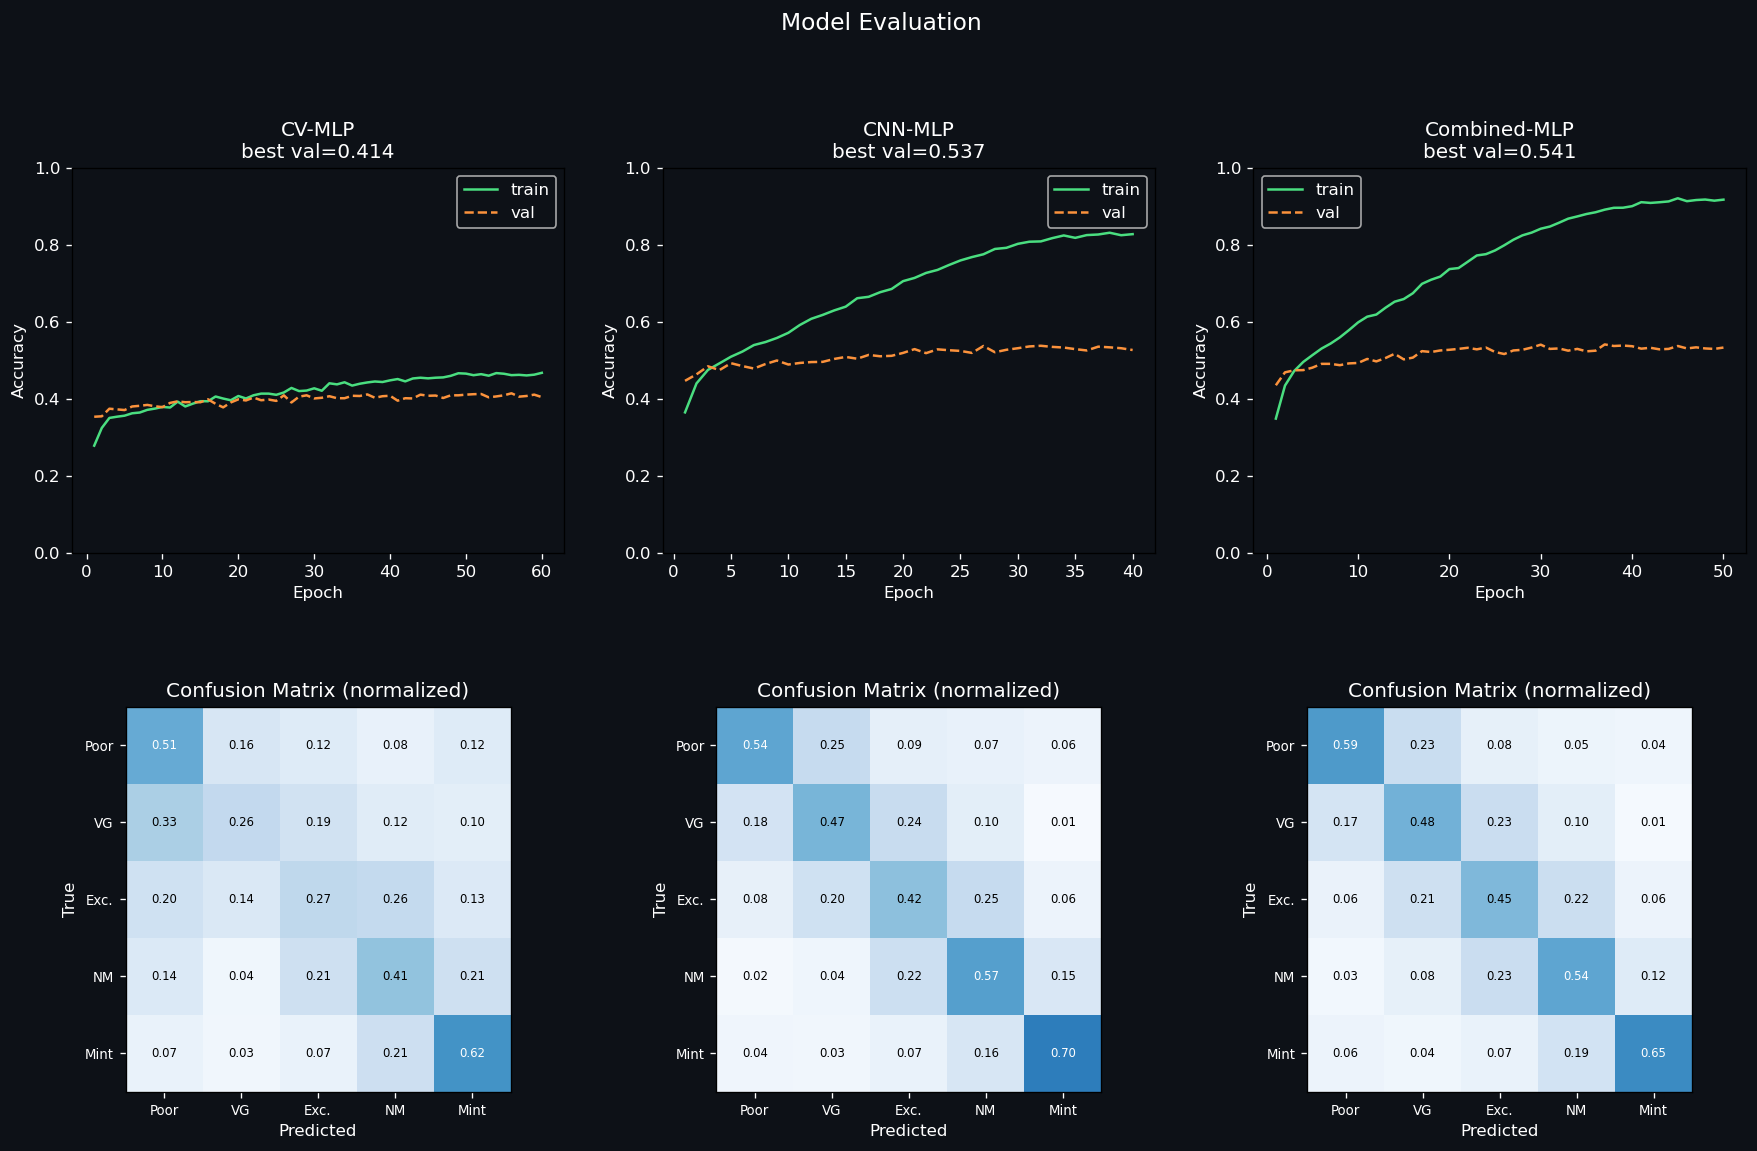

In [11]:
if not trained_models:
    print('Train models first (Step 7)')
else:
    from sklearn.metrics import confusion_matrix

    n_models = len(trained_models)
    fig = plt.figure(figsize=(6 * n_models, 10))
    gs  = gridspec.GridSpec(2, n_models, figure=fig, hspace=0.4)

    for col, (name, model) in enumerate(trained_models.items()):
        h = all_history[name]
        _, val_loader = trained_loaders[name]

        # ── Training curve ────────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, col])
        epochs_range = range(1, len(h['train_acc']) + 1)
        ax1.plot(epochs_range, h['train_acc'], color='#4ade80', label='train')
        ax1.plot(epochs_range, h['val_acc'],   color='#fb923c', label='val', linestyle='--')
        ax1.set_title(f'{name}\nbest val={h["best_val_acc"]:.3f}', color='white')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
        ax1.legend(); ax1.set_ylim(0, 1)

        # ── Confusion matrix ──────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, col])
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for feats, labels in val_loader:
                preds = model(feats.to(DEVICE)).argmax(1).cpu()
                all_preds.extend(preds.tolist())
                all_true.extend(labels.tolist())

        cm = confusion_matrix(all_true, all_preds, labels=list(range(NUM_CLASSES)))
        cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

        im = ax2.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        tick_labels = ['Poor', 'VG', 'Exc.', 'NM', 'Mint']
        ax2.set_xticks(range(NUM_CLASSES)); ax2.set_xticklabels(tick_labels, fontsize=8)
        ax2.set_yticks(range(NUM_CLASSES)); ax2.set_yticklabels(tick_labels, fontsize=8)
        ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
        ax2.set_title('Confusion Matrix (normalized)', color='white')
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                txt = f'{cm_norm[i,j]:.2f}'
                ax2.text(j, i, txt, ha='center', va='center',
                         color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=7)

    plt.suptitle('Model Evaluation', color='white', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## Step 9 — CV Feature Importance

Which CV features matter most for predicting grade?
Computed via **permutation importance** on the CV-MLP model.
Uses all features in the current CV mode (20-dim base or 71-dim extended).

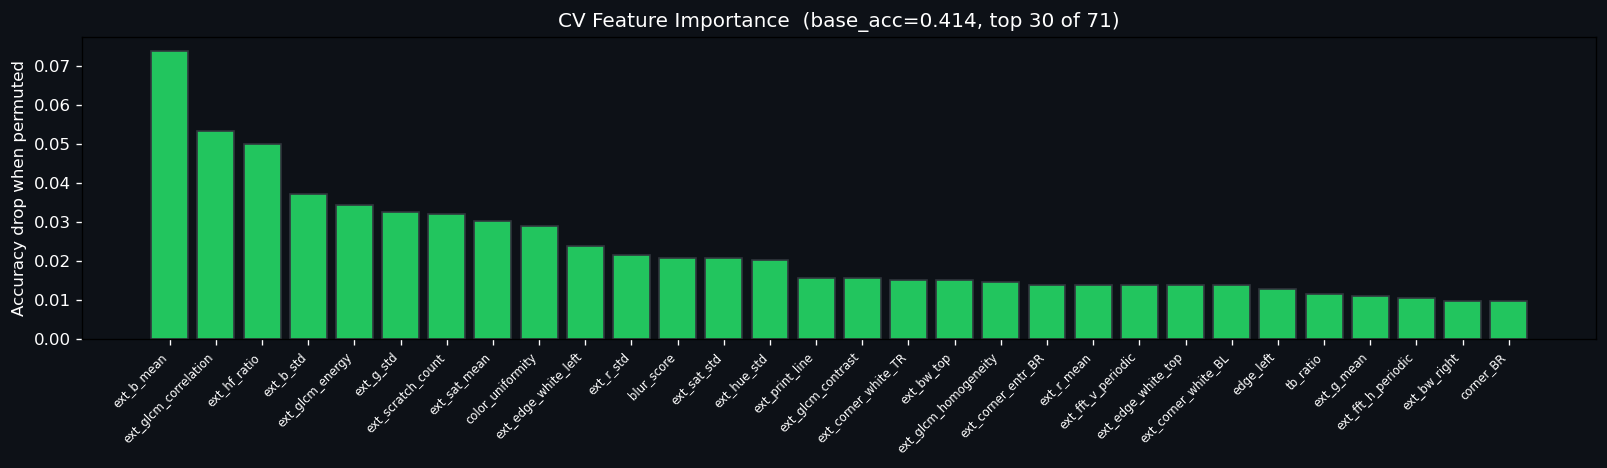

Top 10 most important CV features (out of 71):
   1. ext_b_mean                           drop=+0.0736
   2. ext_glcm_correlation                 drop=+0.0533
   3. ext_hf_ratio                         drop=+0.0499
   4. ext_b_std                            drop=+0.0371
   5. ext_glcm_energy                      drop=+0.0342
   6. ext_g_std                            drop=+0.0325
   7. ext_scratch_count                    drop=+0.0319
   8. ext_sat_mean                         drop=+0.0301
   9. color_uniformity                     drop=+0.0290
  10. ext_edge_white_left                  drop=+0.0238


In [12]:
if 'CV-MLP' not in trained_models:
    print('Train CV-MLP first')
else:
    cv_model = trained_models['CV-MLP'].eval()
    _, val_loader = trained_loaders['CV-MLP']

    # Collect all val features + labels
    all_feats, all_labels = [], []
    for feats, labels in val_loader:
        all_feats.append(feats)
        all_labels.append(labels)
    all_feats  = torch.cat(all_feats).to(DEVICE)
    all_labels = torch.cat(all_labels).to(DEVICE)

    # Use actual feature dim from the data (works for both 20-dim base and 71-dim extended)
    n_cv_feats   = all_feats.shape[1]
    feat_names   = CV_COLS_USED   # set in cache-extract cell (20 or 71 names)

    def accuracy(feats, labels):
        with torch.no_grad():
            preds = cv_model(feats).argmax(1)
        return (preds == labels).float().mean().item()

    base_acc = accuracy(all_feats, all_labels)
    importances = []
    for i in range(n_cv_feats):
        shuffled = all_feats.clone()
        idx = torch.randperm(shuffled.shape[0])
        shuffled[:, i] = shuffled[idx, i]   # permute column i only
        drop = base_acc - accuracy(shuffled, all_labels)
        importances.append(drop)

    # ── Plot top-N features ───────────────────────────────────────
    TOP_N = min(30, n_cv_feats)   # cap at 30 for readability
    imp   = np.array(importances)
    order = np.argsort(imp)[::-1][:TOP_N]

    fig, ax = plt.subplots(figsize=(max(12, TOP_N * 0.45), 4))
    colors = ['#22c55e' if imp[i] > 0 else '#ef4444' for i in order]
    ax.bar(range(TOP_N), imp[order], color=colors, edgecolor='#30363d')
    ax.set_xticks(range(TOP_N))
    ax.set_xticklabels([feat_names[i] for i in order],
                       rotation=45, ha='right', fontsize=7)
    ax.axhline(0, color='white', linewidth=0.5)
    ax.set_ylabel('Accuracy drop when permuted')
    ax.set_title(
        f'CV Feature Importance  (base_acc={base_acc:.3f}, '
        f'top {TOP_N} of {n_cv_feats})',
        color='white'
    )
    plt.tight_layout()
    plt.show()

    print(f'Top 10 most important CV features (out of {n_cv_feats}):')
    for rank, i in enumerate(np.argsort(imp)[::-1][:10]):
        print(f'  {rank+1:>2}. {feat_names[i]:<35}  drop={imp[i]:+.4f}')

## Step 10 — Save Best Model

In [13]:
if not trained_models:
    print('No models trained yet')
else:
    # Pick model with best val accuracy
    best_name  = max(all_history, key=lambda n: all_history[n]['best_val_acc'])
    best_model = trained_models[best_name]
    best_acc   = all_history[best_name]['best_val_acc']
    cfg        = MODEL_CONFIGS[best_name]

    save_path = Path('grade_mlp_best.pt')
    torch.save({
        'model_state':   best_model.state_dict(),
        'model_name':    best_name,
        'mode':          cfg['mode'],
        'hidden_dims':   cfg['hidden_dims'],
        'dropout':       cfg['dropout'],
        'input_dim':     best_model.net[0].in_features,
        'num_classes':   NUM_CLASSES,
        'val_acc':       best_acc,
        'bucket_names':  BUCKET_NAMES,
        # CV feature names — respects USE_EXTENDED_CV flag (20 or 71 names)
        'feature_names': CV_COLS_USED,
        'cv_mode':       _cv_suffix,
        'backbone':      TIMM_BACKBONE,
    }, save_path)

    print(f'✅ Best model: {best_name}  (val_acc={best_acc:.3f})')
    print(f'   CV mode   : {_cv_suffix}  ({CV_DIM_USED}-dim)')
    print(f'   Backbone  : {TIMM_BACKBONE}  ({CNN_DIM}-dim)')
    print(f'   Saved to  : {save_path}')
    print()
    print('To reload and predict:')
    print("  ckpt  = torch.load('grade_mlp_best.pt')")
    print("  model = GradeMLP(ckpt['input_dim'], hidden_dims=ckpt['hidden_dims'])")
    print("  model.load_state_dict(ckpt['model_state'])")
    print("  model.eval()")

✅ Best model: Combined-MLP  (val_acc=0.541)
   CV mode   : ext  (71-dim)
   Backbone  : convnext_tiny.fb_in22k_ft_in1k  (768-dim)
   Saved to  : grade_mlp_best.pt

To reload and predict:
  ckpt  = torch.load('grade_mlp_best.pt')
  model = GradeMLP(ckpt['input_dim'], hidden_dims=ckpt['hidden_dims'])
  model.load_state_dict(ckpt['model_state'])
  model.eval()
